# 504: Peak Warming and ZEC* vs. Net-Zero CO2 Year, ZEC50 validation

Output:
- `504_Figure_2.png`
- `504_SFigure_2.png`
- `504_SFigure_1.png`

In [17]:
import os
from pathlib import Path

import dotenv
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats as scipy_stats
from scipy.stats import gaussian_kde
import numpy as np
from matplotlib.lines import Line2D

dotenv.load_dotenv()

OUTPUT_FOLDER = Path(os.environ["OUTPUT_FOLDER"])
PLOT_FOLDER = OUTPUT_FOLDER / "plots"
PLOT_FOLDER.mkdir(parents=True, exist_ok=True)


In [18]:
# Load cumulative net-negative CO2 and CH4 decline groups from 201

meta_105 = pd.read_csv(OUTPUT_FOLDER / "201_netzero_timings_cumnetnegco2.csv")
meta_105["scenario_group"]="Scenarios (NZCO2)"
meta_105_svnzco2 = pd.read_csv(OUTPUT_FOLDER / "201_netzero_timings_cumnetnegco2-svnzco2.csv")
meta_105_svnzghg = pd.read_csv(OUTPUT_FOLDER / "201_netzero_timings_cumnetnegco2-svnzghg.csv")

In [19]:
# Input metrics file
MANIFEST_ID = "regenerated"
METRICS_FILE = OUTPUT_FOLDER / f"500b_component_metrics_extended_{MANIFEST_ID}.csv"

metrics_df = pd.read_csv(METRICS_FILE, index_col=0)
metrics_df["scenario"] = metrics_df["scenario"].str.replace("_NZCO2", "", regex=False).str.replace("_NZKyoto", "", regex=False)

print(f"Loaded {len(metrics_df):,} runs")

Loaded 1,405,200 runs


In [20]:
# Get model/scenario combinations from Scenarios (NZGHG) group
nzghg_combos = (
    metrics_df[metrics_df["scenario_group"] == "Scenarios (NZGHG)"]
    [["model", "scenario"]]
    .drop_duplicates()
)

# Filter meta_105 to only those combinations
meta_105_nzghg = meta_105.merge(
    nzghg_combos,
    on=["model", "scenario"],
    how="inner"
)

meta_105_nzghg["scenario_group"] = "Scenarios (NZGHG)"
print(f"Scenarios in Scenarios (NZGHG): {len(nzghg_combos)}")
print(f"Matched in meta_105: {len(meta_105_nzghg)}")

Scenarios in Scenarios (NZGHG): 387
Matched in meta_105: 387


In [21]:
meta_105_new = pd.concat([meta_105, meta_105_nzghg, meta_105_svnzco2, meta_105_svnzghg])

meta_105_new = meta_105_new[["model", "scenario", "scenario_group", "cumulative_netnegative_co2", "ch4_decline", "ch4_decline_group"]].copy()

In [22]:
# Merge with metrics_df
metrics_df = metrics_df.merge(meta_105_new, on=["model", "scenario", "scenario_group"], how="left")
#print(f"Merged metadata for {metrics_df['cumulative_netnegative_co2'].notna().sum():,} runs")

metrics_df.head()

,model,scenario,run_id,peak_year,year_netzero_co2,GSAT|ANTHROPOGENIC|peak,GSAT|ANTHROPOGENIC|netzero_co2,GSAT|ANTHROPOGENIC|2100,GSAT|NonCO2_GHG|peak_gsat,GSAT|NonCO2_GHG|2100,...,GSAT|CO2_Negative|2100,GSAT|CO2_Negative|delta_peak_gsat,GSAT|CO2_Negative|netzero_co2,GSAT|CO2_Negative|delta_netzero_co2,scenario_group,GSAT|ANTHROPOGENIC|delta_netzero_co2,GSAT|ANTHROPOGENIC|delta_peak_gsat,cumulative_netnegative_co2,ch4_decline,ch4_decline_group
0,AIM/CGE 2.0,SSP1-19,0,2050,2056,1.656111,1.634448,1.437896,0.061244,-0.066797,...,-0.085296,-0.085296,0.0,-0.085296,Scenarios (NZCO2),-0.196552,-0.218215,-163.45,261.96,High CH4 decline
1,AIM/CGE 2.0,SSP1-19,1,2079,2056,2.578803,2.528323,2.562571,0.266446,0.229079,...,-0.130362,-0.086291,0.0,-0.130362,Scenarios (NZCO2),0.034248,-0.016233,-163.45,261.96,High CH4 decline
2,AIM/CGE 2.0,SSP1-19,2,2049,2056,1.792385,1.769938,1.576141,0.069950,-0.073931,...,-0.090658,-0.090658,0.0,-0.090658,Scenarios (NZCO2),-0.193797,-0.216244,-163.45,261.96,High CH4 decline
3,AIM/CGE 2.0,SSP1-19,3,2041,2056,1.401658,1.343172,1.100911,0.093232,-0.101614,...,-0.068584,-0.068584,0.0,-0.068584,Scenarios (NZCO2),-0.242261,-0.300746,-163.45,261.96,High CH4 decline
4,AIM/CGE 2.0,SSP1-19,4,2049,2056,1.667239,1.636622,1.412878,0.135616,-0.027525,...,-0.082267,-0.082267,0.0,-0.082267,Scenarios (NZCO2),-0.223744,-0.254361,-163.45,261.96,High CH4 decline


## KDE helper for panel d)'s histograms


In [23]:
def add_density(ax, data, color, bins=30):
    """Overlay a KDE on the same axis as a histogram, scaled to match its counts.

    gaussian_kde returns a probability density (integrates to 1 over the data's
    range), which is not on the same scale as raw histogram bin counts - plotting
    both without reconciling this makes the KDE's height meaningless relative to
    the bars (whatever a separate, independently auto-scaled axis happens to pick).
    Scaling the KDE by len(data) * bin_width converts it to "expected count per
    bin", the same units as the histogram, so the two are directly, proportionally
    comparable on one shared axis - no twin axis needed.
    """
    data = data.dropna()
    kde = gaussian_kde(data)
    x_range = np.linspace(data.min(), data.max(), 200)
    bin_width = (data.max() - data.min()) / bins
    scale = len(data) * bin_width
    ax.plot(x_range, kde(x_range) * scale, color=color, linewidth=1.5)

## Figure


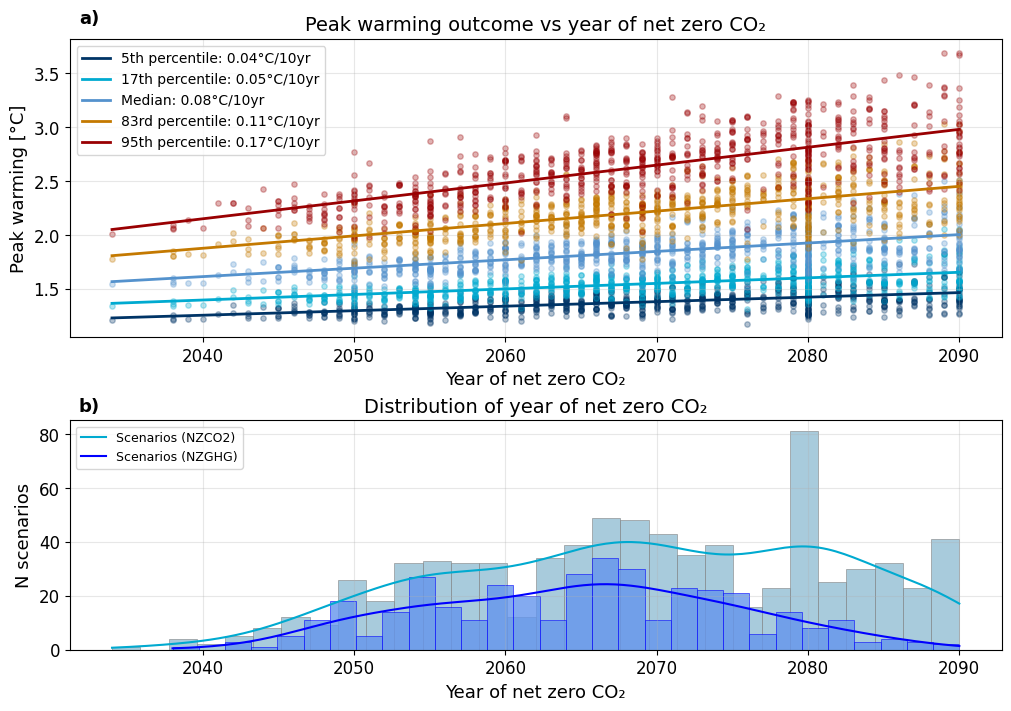

In [24]:
# ------------------------------------------------------------------
# Data prep (shared)
# ------------------------------------------------------------------
scenario_stats = metrics_df.groupby(["model", "scenario", "scenario_group"]).agg({
    "GSAT|ANTHROPOGENIC|peak": [
        lambda x: x.quantile(0.05),
        lambda x: x.quantile(0.17),
        "median",
        lambda x: x.quantile(0.83),
        lambda x: x.quantile(0.95)
    ],
    "year_netzero_co2": "first",
    "cumulative_netnegative_co2": "first",
    "ch4_decline": "first",
    "ch4_decline_group": "first"
}).reset_index()
scenario_stats.columns = [
    "model", "scenario", "scenario_group",
    "peak_p05", "peak_p17", "peak_median", "peak_p83", "peak_p95",
    "year_netzero_co2", "cumulative_netnegative_co2", "ch4_decline", "ch4_decline_group"
]

# Panel a data
plot_data_a = (
    scenario_stats
    .dropna(subset=["year_netzero_co2"])
    .pipe(lambda df: df[df["scenario_group"] == "Scenarios (NZCO2)"])
    .copy()
)
x_all_a = plot_data_a["year_netzero_co2"].values
x_fit_a = np.linspace(x_all_a.min(), x_all_a.max(), 100)

# Panel b data
plot_data_b_nzco2 = (
    scenario_stats
    .dropna(subset=["year_netzero_co2"])
    .pipe(lambda df: df[df["scenario_group"] == "Scenarios (NZCO2)"])
    .copy()
)
plot_data_b_nzghg = (
    scenario_stats
    .dropna(subset=["year_netzero_co2"])
    .pipe(lambda df: df[df["scenario_group"] == "Scenarios (NZGHG)"])
    .copy()
)

# ------------------------------------------------------------------
# Color/label dicts
# ------------------------------------------------------------------
percentile_colors = {
    "peak_p05":    "#003466",
    "peak_p17":    "#00aad0",
    "peak_median": "#5492cd",
    "peak_p83":    "#c47900",
    "peak_p95":    "#990002",
}
percentile_labels = {
    "peak_p05":    "5th percentile",
    "peak_p17":    "17th percentile",
    "peak_median": "Median",
    "peak_p83":    "83rd percentile",
    "peak_p95":    "95th percentile",
}

# ------------------------------------------------------------------
# Figure layout — 2 panels with unequal heights
# ------------------------------------------------------------------
fig, axes = plt.subplots(
    2, 1,
    figsize=(10, 7),
    constrained_layout=True,
    gridspec_kw={"height_ratios": [1.3, 1]}
)
ax_a, ax_b = axes

# ------------------------------------------------------------------
# Panel a) — percentile scatter
# ------------------------------------------------------------------
for col in ["peak_p05", "peak_p17", "peak_median", "peak_p83", "peak_p95"]:
    y = plot_data_a[col].values
    hex_color = percentile_colors[col]
    label = percentile_labels[col]
    ax_a.scatter(x_all_a, y, facecolors=hex_color, edgecolors=hex_color, alpha=0.3, s=15)
    valid = ~np.isnan(y)
    if valid.sum() > 1:
        slope, intercept = np.polyfit(x_all_a[valid], y[valid], 1)
        ax_a.plot(x_fit_a, slope * x_fit_a + intercept,
                  color=hex_color, linewidth=2,
                  label=f"{label}: {slope*10:.2f}°C/10yr")
ax_a.set_xlabel("Year of net zero CO₂", fontsize=13)
ax_a.set_ylabel("Peak warming [°C]", fontsize=13)
ax_a.set_title("Peak warming outcome vs year of net zero CO₂", fontsize=14)
ax_a.legend(fontsize=10, loc="upper left")
ax_a.grid(alpha=0.3)
ax_a.tick_params(axis="both", labelsize=12)

# ------------------------------------------------------------------
# Panel b) — histogram of NZCO2 timing
# ------------------------------------------------------------------
ax_b.hist(
    plot_data_b_nzco2["year_netzero_co2"],
    bins=30, color="#92BFD4", edgecolor="grey", linewidth=0.5, alpha=0.8
)
add_density(ax_b, plot_data_b_nzco2["year_netzero_co2"], color="#00aad0")

ax_b.hist(
    plot_data_b_nzghg["year_netzero_co2"],
    bins=30, color="cornflowerblue", edgecolor="blue", linewidth=0.5, alpha=0.8
)
add_density(ax_b, plot_data_b_nzghg["year_netzero_co2"], color="blue")

ax_b.set_xlabel("Year of net zero CO₂", fontsize=13)
ax_b.set_ylabel("N scenarios", fontsize=13)
ax_b.set_title("Distribution of year of net zero CO₂", fontsize=14)
ax_b.grid(alpha=0.3, zorder=0)
ax_b.tick_params(axis="both", labelsize=12)

legend_handles = [
    Line2D([0], [0], color="#00aad0", linewidth=1.5, label="Scenarios (NZCO2)"),
    Line2D([0], [0], color="blue", linewidth=1.5, label="Scenarios (NZGHG)"),
]
ax_b.legend(handles=legend_handles, fontsize=9, loc="upper left",
            frameon=True, framealpha=0.8)

# ------------------------------------------------------------------
# Panel labels
# ------------------------------------------------------------------
for ax, label in zip([ax_a, ax_b], ["a)", "b)"]):
    ax.annotate(label, xy=(0.01, 1.1), xycoords="axes fraction",
                fontsize=13, fontweight="bold", va="top", ha="left")

plt.savefig(PLOT_FOLDER / "504_Figure_2.png", dpi=300, bbox_inches="tight")
plt.show()


## CH4-Decline


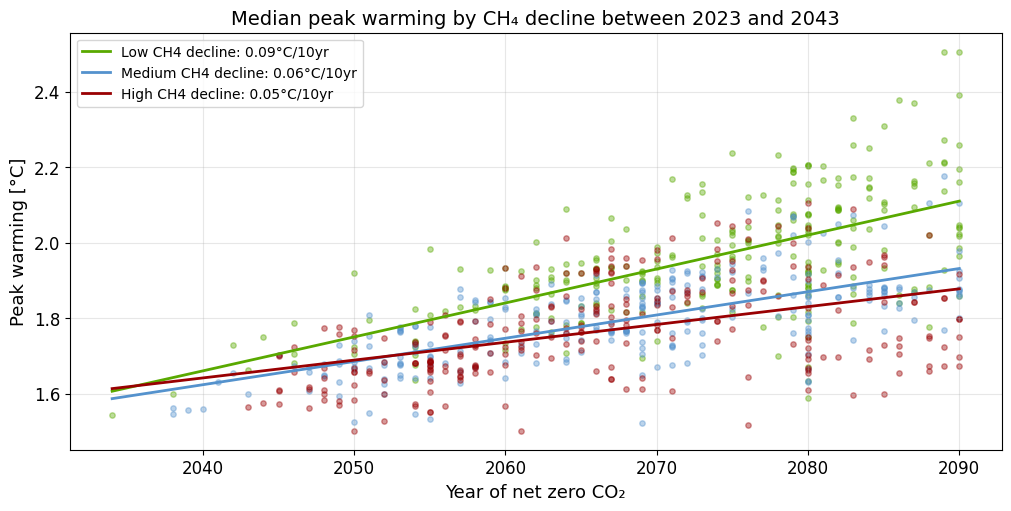

In [25]:
scenario_stats_ch4 = metrics_df.groupby(["model", "scenario", "scenario_group"]).agg({
    "GSAT|ANTHROPOGENIC|peak": "median",
    "year_netzero_co2": "first",
    "ch4_decline_group": "first",
}).reset_index()
scenario_stats_ch4.columns = [
    "model", "scenario", "scenario_group", "peak_median", "year_netzero_co2", "ch4_decline_group",
]

plot_data_ch4 = (
    scenario_stats_ch4
    .dropna(subset=["year_netzero_co2"])
    .pipe(lambda df: df[df["scenario_group"] == "Scenarios (NZCO2)"])
    .copy()
)
x_all_ch4 = plot_data_ch4["year_netzero_co2"].values
x_fit_ch4 = np.linspace(x_all_ch4.min(), x_all_ch4.max(), 100)

GROUP_COLORS = {
    "Low CH4 decline":    "#59a900",
    "Medium CH4 decline": "#5492cd",
    "High CH4 decline":   "#990002",
}

fig, ax = plt.subplots(figsize=(10, 5), constrained_layout=True)

for group in ["Low CH4 decline", "Medium CH4 decline", "High CH4 decline"]:
    subset = plot_data_ch4[plot_data_ch4["ch4_decline_group"] == group]
    x = subset["year_netzero_co2"].values
    y = subset["peak_median"].values
    hex_color = GROUP_COLORS[group]
    ax.scatter(x, y, facecolors=hex_color, edgecolors=hex_color, alpha=0.4, s=15)
    valid = ~np.isnan(y)
    if valid.sum() > 1:
        slope, intercept = np.polyfit(x[valid], y[valid], 1)
        ax.plot(x_fit_ch4, slope * x_fit_ch4 + intercept,
                color=hex_color, linewidth=2,
                label=f"{group}: {slope*10:.2f}°C/10yr")

ax.set_xlabel("Year of net zero CO₂", fontsize=13)
ax.set_ylabel("Peak warming [°C]", fontsize=13)
ax.set_title("Median peak warming by CH₄ decline between 2023 and 2043", fontsize=14)
ax.legend(fontsize=10, loc="upper left")
ax.grid(alpha=0.3)
ax.tick_params(axis="both", labelsize=12)

plt.savefig(PLOT_FOLDER / "504_SFigure_2.png", dpi=300, bbox_inches="tight")
plt.show()


## ZEC50 Validation

Compares the full-member-pool ZEC50 distribution (Scenarios (NZCO2), rescaled to
a standardized 50-year window per member) against external assessments (AR6 assessed
likely range, ZECMIP, flat10 MAGICC6) - histogram + KDE in the bottom panel, all four
ranges as horizontal box plots stacked in the top panel. Uses the same `metrics_df`
already loaded above.


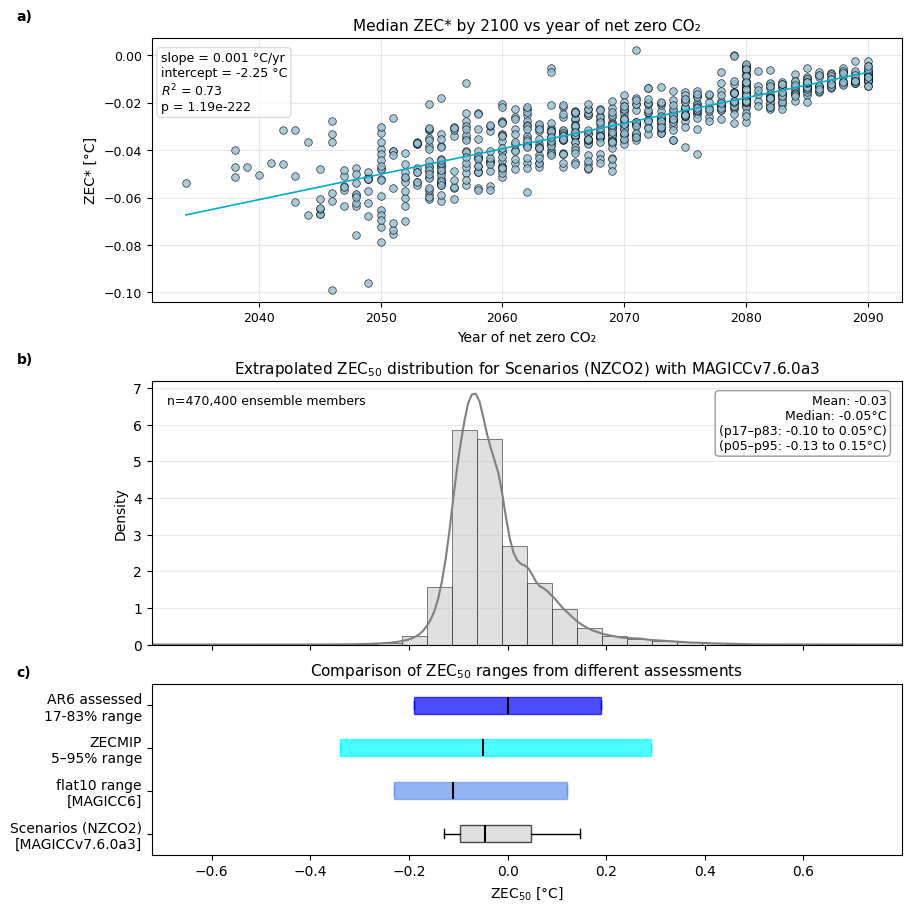

In [26]:
# Use full member pool (not scenario medians) for ZEC50
metrics_df["ZEC50"] = (
    metrics_df["GSAT|CO2_NZCO2|delta_netzero_co2"]
    * 50
    / (2100 - metrics_df["year_netzero_co2"])
)

# Panel a) data: this is the raw ZEC* (delta_netzero_co2), not ZEC50
# scenario-median-per-scenario basis
plot_data_c = (
    metrics_df[metrics_df["scenario_group"] == "Stylised Variants (NZCO2-hold)"]
    .groupby(["model", "scenario"])[
        ["GSAT|CO2_NZCO2|delta_netzero_co2", "GSAT|ANTHROPOGENIC|peak", "year_netzero_co2"]
    ]
    .median()
    .reset_index()
    .dropna(subset=["GSAT|CO2_NZCO2|delta_netzero_co2", "year_netzero_co2"])
)
x_c = plot_data_c["year_netzero_co2"].values
y_c = plot_data_c["GSAT|CO2_NZCO2|delta_netzero_co2"].values
slope_c, intercept_c, r_value_c, p_value_c, _ = scipy_stats.linregress(x_c, y_c)
x_fit_c = np.linspace(x_c.min(), x_c.max(), 100)
y_fit_c = slope_c * x_fit_c + intercept_c

fig, (ax_c, ax_hist, ax_box) = plt.subplots(
    3, 1, figsize=(9, 9),
    gridspec_kw={"height_ratios": [2, 2, 1.3]},
    constrained_layout=True,
)
ax_hist.sharex(ax_box)  # panels b/c share the ZEC50 x-axis; panel a has its own (year)

group = "Scenarios (NZCO2)"
hist_color = "lightgrey"
kde_color = "gray"
edge_color = "black"

# Full member pool
gdata = metrics_df[metrics_df["scenario_group"] == group]["ZEC50"].dropna()
x_min, x_max = gdata.min(), gdata.max()
x_range = np.linspace(x_min, x_max, 200)

# Percentiles
mean = gdata.mean()
p05 = gdata.quantile(0.05)
p17 = gdata.quantile(0.17)
p50 = gdata.median()
p83 = gdata.quantile(0.83)
p95 = gdata.quantile(0.95)

# --- panel b: histogram + KDE of the full member pool ---
ax_hist.hist(
    gdata,
    bins=30,
    color=hist_color,
    edgecolor="black",
    linewidth=0.5,
    alpha=0.7,
    density=True,
)

if len(gdata) > 1:
    kde = gaussian_kde(gdata)
    ax_hist.plot(x_range, kde(x_range), color=kde_color, linewidth=1.5)

ax_hist.set_xlim(x_min, x_max)
ax_hist.set_ylim(0, None)
ax_hist.set_ylabel("Density")
ax_hist.grid(alpha=0.3, axis="y")
ax_hist.tick_params(axis="x", labelbottom=False)  # x labels only on panel c below, which shares this axis

ax_hist.annotate(
    f"Mean: {mean:.2f}\nMedian: {p50:.2f}°C\n(p17–p83: {p17:.2f} to {p83:.2f}°C)\n(p05–p95: {p05:.2f} to {p95:.2f}°C)",
    xy=(0.98, 0.95),
    xycoords="axes fraction",
    fontsize=9,
    va="top",
    ha="right",
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor=kde_color, alpha=0.8)
)
ax_hist.annotate(
    f"n={len(gdata):,} ensemble members",
    xy=(0.02, 0.95),
    xycoords="axes fraction",
    fontsize=9,
    va="top",
    ha="left",
)

ax_hist.set_title(
    "Extrapolated ZEC$_{50}$ distribution for Scenarios (NZCO2) with MAGICCv7.6.0a3",
    fontsize=11,
)

# --- panel c: box plots - full member pool plus other assessments, stacked ---
box_stats = [{
    "label": "Scenarios (NZCO2)\n[MAGICCv7.6.0a3]",
    "med": p50,
    "q1": p17,
    "q3": p83,
    "whislo": p05,
    "whishi": p95,
    "fliers": [],
}]
box_colors = [hist_color]

# Other assessments only give a [low, central, high] triple each - represented as a
# box spanning low-high with a median line at the central estimate. No separate
# whiskers, since there's no wider percentile range available for these
reference_ranges = {
    "flat10 range\n[MAGICC6]": {"values": [-0.23, -0.11, 0.12], "color": "cornflowerblue"},
    "ZECMIP\n5–95% range": {"values": [-0.34, -0.05, 0.29], "color": "cyan"},
    "AR6 assessed\n17-83% range": {"values": [-0.19, 0.0, 0.19], "color": "blue", "edgecolor": "black"},
}

for label, cfg in reference_ranges.items():
    lo, central, hi = cfg["values"]
    box_stats.append({
        "label": label,
        "med": central,
        "q1": lo,
        "q3": hi,
        "whislo": lo,
        "whishi": hi,
        "fliers": [],
    })
    box_colors.append(cfg["color"])

bp = ax_box.bxp(
    box_stats,
    vert=False,
    patch_artist=True,
    widths=0.4,
)
for patch, color in zip(bp["boxes"], box_colors):
    patch.set_facecolor(color)
    patch.set_edgecolor(edge_color if color == hist_color else color)
    patch.set_alpha(0.7)
for element in ("whiskers", "caps"):
    for i, line in enumerate(bp[element]):
        color = box_colors[i // 2]
        line.set_color(edge_color if color == hist_color else color)
for line in bp["medians"]:
    line.set_color("black")
    line.set_linewidth(1.5)

# "Scenarios (NZCO2)" first in box_stats (bottom by default) - flip so it's on top,
# ahead of the reference assessments.
#ax_box.invert_yaxis()
ax_box.set_xlabel("ZEC$_{50}$ [°C]")  # now the bottom-most panel of the shared b/c axis

ax_box.set_title(
    "Comparison of ZEC$_{50}$ ranges from different assessments",
    fontsize=11,
)

# --- panel a: ZEC* scatter with regression ---
ax_c.scatter(
    plot_data_c["year_netzero_co2"],
    plot_data_c["GSAT|CO2_NZCO2|delta_netzero_co2"],
    c="#92BFD4",
    alpha=0.8,
    s=30,
    edgecolors="black",
    linewidths=0.5,
    zorder=2
)
ax_c.plot(x_fit_c, y_fit_c, color="#00aad0", linewidth=1.2, label="Linear fit", zorder=3)
ax_c.text(
    0.012, 0.714,
    f"slope = {slope_c:.3f} °C/yr\nintercept = {intercept_c:.2f} °C\n$R^2$ = {r_value_c**2:.2f}\np = {p_value_c:.2e}",
    transform=ax_c.transAxes,
    fontsize=9,
    va="bottom",
    ha="left",
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="lightgrey", alpha=0.8)
)
ax_c.set_xlabel("Year of net zero CO₂", fontsize=10)
ax_c.set_ylabel("ZEC* [°C]", fontsize=10)
ax_c.set_title("Median ZEC* by 2100 vs year of net zero CO₂", fontsize=11)
ax_c.grid(alpha=0.3, zorder=0)
ax_c.tick_params(axis="both", labelsize=9)

# --- panel labels ---
for ax, label in zip([ax_c, ax_hist, ax_box], ["a)", "b)", "c)"]):
    ax.annotate(label, xy=(-0.18, 1.11), xycoords="axes fraction",
                fontsize=10, fontweight="bold", va="top", ha="left")

plt.savefig(PLOT_FOLDER / "504_SFigure_1.png", dpi=300, bbox_inches="tight")
plt.show()